# Person SAHI — yolo26s Person zoomed in (extreme scale variance)

**ELI5:** Imagine one photo has a giant close person (fills screen) AND tiny far persons (dots). Normal YOLO sees both at once but tiny dots are blurry. Cutting into tiny tiles (320) makes giant get chopped into arms/legs -> broken boxes. Fix: use bigger tiles (512) + keep the full photo + glue cut pieces with NMM+IOS so small dots inside big box count as one person.

**Config (Reference):** `512x512 overlap 0.25` + `perform_standard_pred=True` + `GREEDYNMM` + `IOS 0.5`. ponytail minimal: one constant + 4 SAHI args.

**Scope:** Person only, `valid` 114 / `test` 82, `conf 0.25`. Previous 320/0.2: sRec 0.405 flat, box F1 0.775->0.647, 9.6x cost — giants sliced.


## 1 · Setup


In [1]:
import time, random, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, cv2
from ultralytics import YOLO

sns.set_theme(style="whitegrid")
random.seed(42); np.random.seed(42)
print("ultralytics:", __import__("ultralytics").__version__)

try:
    _nb = Path(__file__)
    REPO_ROOT = _nb.resolve().parents[2]
except NameError:
    cur = Path.cwd()
    REPO_ROOT = cur
    for cand in [cur, cur.parent, cur.parent.parent]:
        if (cand / "YOLO8.ipynb").exists() or (cand / ".git").exists():
            REPO_ROOT = cand; break
print("REPO_ROOT:", REPO_ROOT)

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import sahi; print("sahi:", sahi.__version__)


ultralytics: 8.4.127
REPO_ROOT: e:\work\P0-safety
sahi: 0.12.6


## 2 · Data

`data/` is gitignored. If missing, visuals skip with hint.


In [2]:
CLASS_NAMES = ["Hardhat","Mask","NO-Hardhat","NO-Mask","NO-Safety Vest","Person","Safety Cone","Safety Vest","machinery","vehicle"]
PERSON_CLS = CLASS_NAMES.index("Person")
DATA_DIR = REPO_ROOT / "data" / "css-data"
for split in ["train","valid","test"]:
    img_dir = DATA_DIR / split / "images"
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    print(f"{split:6s} images={n_img:5d} exists={img_dir.exists()}")


train  images= 2605 exists=True
valid  images=  114 exists=True
test   images=   82 exists=True


## 3 · Models — yolo26s single-pass + sahi wrapper (same weights)


In [3]:
yolo26s_path = REPO_ROOT / "experiment" / "two-stage-detection" / "yolo26s.pt"
if not yolo26s_path.exists():
    yolo26s_path = Path("yolo26s.pt")
print("yolo26s_path:", yolo26s_path, "exists:", yolo26s_path.exists())

# single-pass baseline (direct YOLO)
model_person = YOLO(str(yolo26s_path))
print("single-pass:", list(model_person.names.values())[:3], f"({len(model_person.names)} cls)")

# sahi wrapper — same weights, sahi handles tiling + NMS internally
sahi_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=str(yolo26s_path),
    confidence_threshold=0.25,
    device="cpu",
)
print("sahi_model:", sahi_model.model_path, "conf:", sahi_model.confidence_threshold)


yolo26s_path: e:\work\P0-safety\experiment\two-stage-detection\yolo26s.pt exists: True
single-pass: ['person', 'bicycle', 'car'] (80 cls)
sahi_model: e:\work\P0-safety\experiment\two-stage-detection\yolo26s.pt conf: 0.25


## 4 · Helpers — Person GT + single-pass extract + IoU matching


In [4]:
def person_class_id(model):
    for k,v in model.names.items():
        if v=="person": return k
    return 0

def extract_person_boxes(result, model, conf_thr=0.25):
    if result.boxes is None or len(result.boxes)==0: return []
    pid=person_class_id(model)
    out=[]
    for i in range(len(result.boxes)):
        if int(result.boxes.cls[i].item())==pid and float(result.boxes.conf[i].item())>=conf_thr:
            x1,y1,x2,y2=result.boxes.xyxy[i].tolist()
            out.append([x1,y1,x2,y2,float(result.boxes.conf[i].item())])
    return out

def parse_person_gt(label_path, W=640, H=640):
    p=Path(label_path)
    out=[]
    if not p.exists(): return out
    for line in p.read_text().splitlines():
        if not line.strip(): continue
        parts=line.split(); cid=int(parts[0])
        if cid==PERSON_CLS:
            cx,cy,w,h=map(float, parts[1:5])
            x1,y1=cx*W - w*W/2, cy*H - h*H/2
            x2,y2=cx*W + w*W/2, cy*H + h*H/2
            out.append([x1,y1,x2,y2])
    return out

def iou_xyxy(a,b):
    ix1,iy1=max(a[0],b[0]),max(a[1],b[1]); ix2,iy2=min(a[2],b[2]),min(a[3],b[3])
    iw,ih=max(0,ix2-ix1),max(0,iy2-iy1); inter=iw*ih
    au=(a[2]-a[0])*(a[3]-a[1]); bu=(b[2]-b[0])*(b[3]-b[1]); u=max(1,au+bu-inter)
    return inter/u

def match_person(pred_xyxy, gt_xyxy, iou_thr=0.5):
    pred_sorted=sorted(pred_xyxy, key=lambda x: x[4] if len(x)>4 else 1, reverse=True)
    matched=[False]*len(gt_xyxy); tp=fp=0
    for p in pred_sorted:
        best,bi=-1,-1
        for i,g in enumerate(gt_xyxy):
            if matched[i]: continue
            s=iou_xyxy(p[:4], g)
            if s>best: best,bi=s,i
        if best>=iou_thr: tp+=1; matched[bi]=True
        else: fp+=1
    fn=sum(1 for m in matched if not m)
    return tp,fp,fn

def has_person_gt(label_path):
    return len(parse_person_gt(label_path)) > 0


## 5 · SAHI Person — one function, 320/0.2, ponytail minimal


In [5]:
# ponytail: extreme scale variance — one Person class is both tiny (7px far) and giant (500px close).
# Reference: keep full-image + NMM + IOS + big slices so giant stays whole, tiny gets zoom, limbs merge not cut.
SLICE=512; OVERLAP=0.25  # was 320/0.2 — 320 cut giants into limbs, IOS+NMM needs context

def sahi_person_boxes(img_path, slice_height=SLICE, slice_width=SLICE, overlap=OVERLAP, conf_thr=0.25):
    sahi_model.confidence_threshold = conf_thr
    result = get_sliced_prediction(
        str(img_path),
        sahi_model,
        slice_height=slice_height,
        slice_width=slice_width,
        overlap_height_ratio=overlap,
        overlap_width_ratio=overlap,
        perform_standard_pred=True,  # keep full-image: giant person stays whole
        postprocess_type="GREEDYNMM",  # NMM merges limbs, not NMS which drops them
        postprocess_match_metric="IOS",  # small slice fragment inside big box = same person
        postprocess_match_threshold=0.5,
        verbose=0,
    )
    out=[]
    for pred in result.object_prediction_list:
        name = str(pred.category.name).lower() if hasattr(pred.category, 'name') else str(pred.category.id)
        if name == "person" or pred.category.id == 0:
            x1,y1,x2,y2 = pred.bbox.minx, pred.bbox.miny, pred.bbox.maxx, pred.bbox.maxy
            out.append([x1,y1,x2,y2, float(pred.score.value)])
    return out

print("sahi_person_boxes ready — slice", SLICE, "overlap", OVERLAP, "GREEDYNMM+IOS full-image")


sahi_person_boxes ready — slice 512 overlap 0.25 GREEDYNMM+IOS full-image


## 6 · Visual — 4 images: left single-pass (green) vs right SAHI (orange), white = GT


sample: ['youtube-226_jpg.rf.dd9d045ca17155289bcebe722e8a86e9.jpg', '2009_000461_jpg.rf.43a28e2d6f1f9d399c92e18ccc9f0bf1.jpg', '-1989-_png_jpg.rf.8cb3d6087bb86d08e693b4250fbf96e3.jpg', 'youtube-399_jpg.rf.3472ef7c01bb9092da48f0d562581121.jpg']
youtube-226_jpg.rf.dd9d045ca17155289bcebe722e8a86e9.jpg GT=0 single=0 sahi=0 extra=0


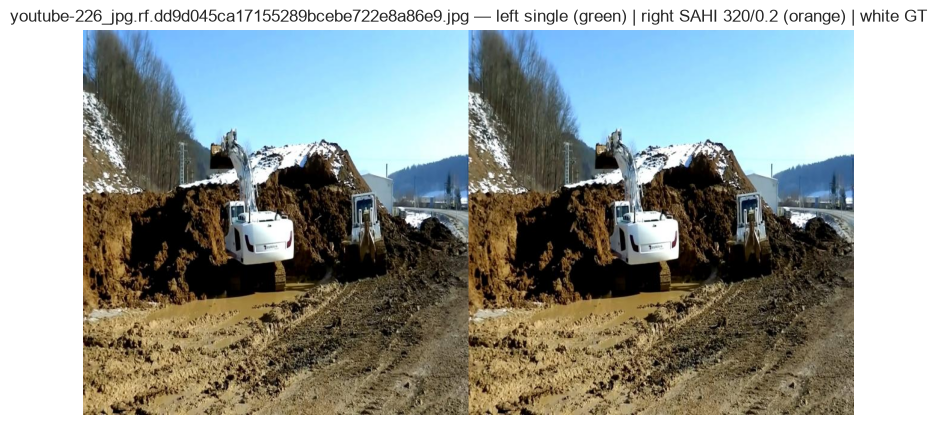

2009_000461_jpg.rf.43a28e2d6f1f9d399c92e18ccc9f0bf1.jpg GT=1 single=1 sahi=1 extra=0


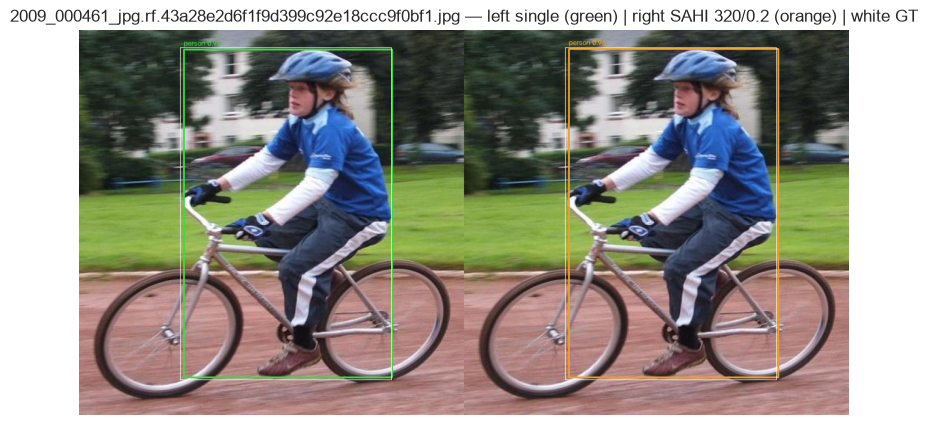

-1989-_png_jpg.rf.8cb3d6087bb86d08e693b4250fbf96e3.jpg GT=6 single=4 sahi=3 extra=-1


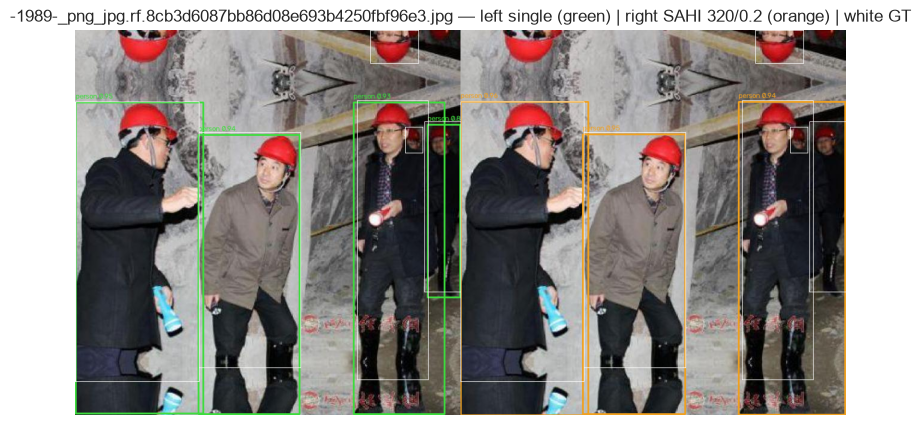

youtube-399_jpg.rf.3472ef7c01bb9092da48f0d562581121.jpg GT=0 single=0 sahi=0 extra=0


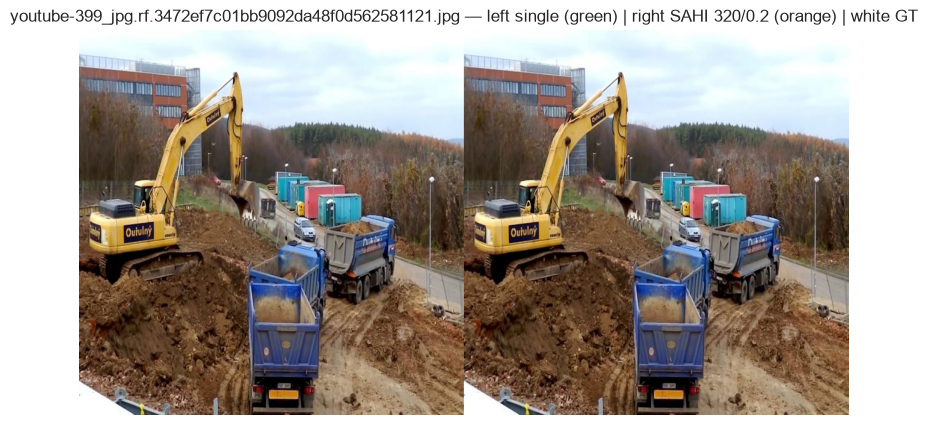

In [6]:
def draw_boxes(img, boxes, color):
    out=img.copy()
    for b in boxes:
        x1,y1,x2,y2=b[0],b[1],b[2],b[3]; conf=b[4] if len(b)>4 else 1.0
        cv2.rectangle(out,(int(x1),int(y1)),(int(x2),int(y2)),color,2)
        cv2.putText(out,f"person {conf:.2f}",(int(x1),max(14,int(y1)-6)),cv2.FONT_HERSHEY_SIMPLEX,0.42,color,1,cv2.LINE_AA)
    return out

CONF=0.25
if not DATA_DIR.exists():
    print("Need data/css-data for viz")
else:
    pool=list((DATA_DIR / "valid" / "images").glob("*.jpg"))
    sample=random.sample(pool, min(4, len(pool))) if pool else []
    print("sample:", [p.name for p in sample])
    for img_path in sample:
        img=cv2.imread(str(img_path)); rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        H,W=rgb.shape[:2]
        # single-pass
        r=model_person(str(img_path), verbose=False, imgsz=640)[0]
        single=extract_person_boxes(r, model_person, CONF)
        # sahi
        sliced=sahi_person_boxes(img_path, SLICE, SLICE, OVERLAP, CONF)
        gt=parse_person_gt(str(DATA_DIR / "valid" / "labels" / (img_path.stem+".txt")), W, H)
        gt_count=len(gt)
        print(f"{img_path.name:30s} GT={gt_count} single={len(single)} sahi={len(sliced)} extra={len(sliced)-len(single)}")
        left=draw_boxes(rgb, single, (60,220,60))
        right=draw_boxes(rgb, sliced, (240,160,30))
        # overlay GT white on both for reference
        for x1,y1,x2,y2 in gt:
            cv2.rectangle(left,(int(x1),int(y1)),(int(x2),int(y2)),(255,255,255),1)
            cv2.rectangle(right,(int(x1),int(y1)),(int(x2),int(y2)),(255,255,255),1)
        strip=np.concatenate([left,right], axis=1)
        plt.figure(figsize=(12,5)); plt.imshow(strip); plt.axis("off")
        plt.title(f"{img_path.name} — left single (green) | right SAHI 320/0.2 (orange) | white GT")
        plt.show()


## 7 · Quant — image-level + box-level P/R/F1 (valid tuning, test locked)

Image-level: does the image have a Person? Box-level: IoU 0.5 matching. ponytail: image-level first, box-level only matters if image-level moves.


=== Person detection — single-pass vs SAHI slice 512 overlap 0.25 conf 0.25 ===
valid single  img P=1.000 R=0.810 F1=0.895  box P=0.911 R=0.675 F1=0.775  sRec=0.405  ms=91  n=114
valid SAHI    img P=1.000 R=0.845 F1=0.916  box P=0.909 R=0.663 F1=0.767  sRec=0.381  ms=422  n=114
test  single  img P=0.961 R=0.831 F1=0.891  box P=0.919 R=0.655 F1=0.765  sRec=0.204  ms=89  n=82
test  SAHI    img P=0.962 R=0.847 F1=0.901  box P=0.879 R=0.626 F1=0.732  sRec=0.204  ms=425  n=82


,split,method,n,prec,rec,f1,TP,FP,TN,FN,bprec,brec,bf1,bTP,bFP,bFN,srec,ms
0,valid,single,114,1.000000,0.809524,0.894737,68,0,30,16,0.910569,0.674699,0.775087,112,11,54,0.404762,91.282343
1,valid,SAHI,114,1.000000,0.845238,0.916129,71,0,30,13,0.909091,0.662651,0.766551,110,11,56,0.380952,421.685468
2,test,single,82,0.960784,0.830508,0.890909,49,2,21,10,0.919355,0.655172,0.765101,114,10,60,0.204082,88.750197
3,test,SAHI,82,0.961538,0.847458,0.900901,50,2,21,9,0.879032,0.626437,0.731544,109,15,65,0.204082,425.237336



Valid delta: dR_img=+0.036 dF1_img=+0.021  dR_box=-0.012  dsRec=-0.024  ms 91->422 (4.6x)
Gate: ship SAHI only if Rec gain >=0.03 and Prec drop <=0.03 at ~3-5x cost; else keep single-pass on-demand for far/drone shots.


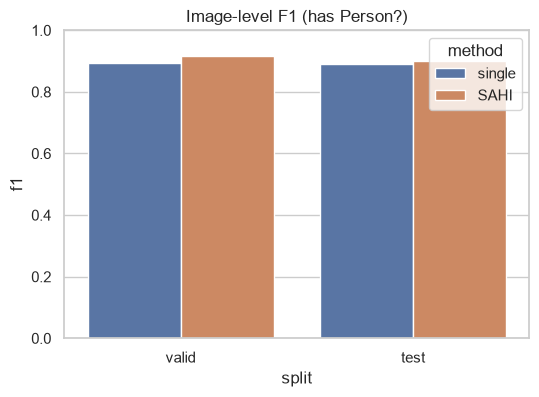

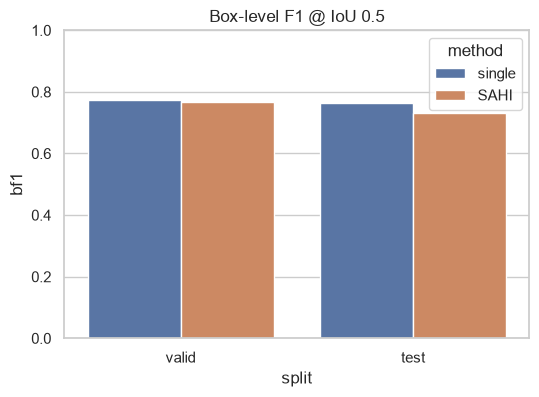

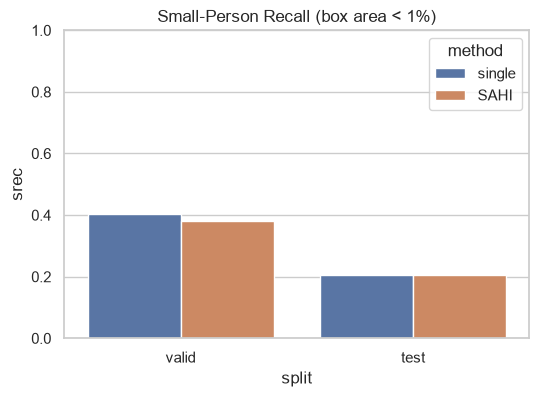

In [7]:
def eval_split(split, use_sahi=False, conf_thr=0.25, iou_thr=0.5, slice=SLICE, overlap=OVERLAP):
    img_dir=DATA_DIR / split / "images"; lbl_dir=DATA_DIR / split / "labels"
    if not img_dir.exists(): return None
    imgs=list(img_dir.glob("*.jpg"))
    # image-level
    TP=FP=TN=FN=0
    # box-level
    bTP=bFP=bFN=0
    times=[]
    small_tp=small_fn=0
    for p in imgs:
        gt_has=has_person_gt(str(lbl_dir / (p.stem+".txt")))
        gt_boxes=parse_person_gt(str(lbl_dir / (p.stem+".txt")))
        # small GT: box area < 1% image
        small_gt=[b for b in gt_boxes if (b[2]-b[0])*(b[3]-b[1]) < 640*640*0.01]
        t0=time.time()
        if use_sahi:
            pred=sahi_person_boxes(p, slice, slice, overlap, conf_thr)
        else:
            r=model_person(str(p), verbose=False, imgsz=640)[0]
            pred=extract_person_boxes(r, model_person, conf_thr)
        times.append((time.time()-t0)*1000)
        pred_has=len(pred)>0
        if gt_has and pred_has: TP+=1
        elif not gt_has and pred_has: FP+=1
        elif not gt_has and not pred_has: TN+=1
        else: FN+=1
        tp,fp,fn=match_person(pred, gt_boxes, iou_thr)
        bTP+=tp; bFP+=fp; bFN+=fn
        if small_gt:
            stp,_,sfn=match_person(pred, small_gt, iou_thr)
            small_tp+=stp; small_fn+=sfn
    prec=TP/max(1,TP+FP); rec=TP/max(1,TP+FN); f1=2*prec*rec/max(1e-9,prec+rec)
    bprec=bTP/max(1,bTP+bFP); brec=bTP/max(1,bTP+bFN); bf1=2*bprec*brec/max(1e-9,bprec+brec)
    srec=small_tp/max(1,small_tp+small_fn) if (small_tp+small_fn)>0 else float('nan')
    return dict(n=len(imgs), prec=prec, rec=rec, f1=f1, TP=TP, FP=FP, TN=TN, FN=FN,
                bprec=bprec, brec=brec, bf1=bf1, bTP=bTP, bFP=bFP, bFN=bFN,
                srec=srec, ms=np.mean(times))

if not DATA_DIR.exists():
    print("Skipping quant — need data/css-data")
else:
    print(f"=== Person detection — single-pass vs SAHI slice {SLICE} overlap {OVERLAP} conf 0.25 ===")
    rows=[]
    for split in ["valid","test"]:
        for sahi in [False, True]:
            r=eval_split(split, use_sahi=sahi, conf_thr=0.25)
            if r:
                tag="SAHI" if sahi else "single"
                rows.append({"split":split,"method":tag,**r})
                print(f"{split:5s} {tag:6s}  img P={r['prec']:.3f} R={r['rec']:.3f} F1={r['f1']:.3f}  box P={r['bprec']:.3f} R={r['brec']:.3f} F1={r['bf1']:.3f}  sRec={r['srec']:.3f}  ms={r['ms']:.0f}  n={r['n']}")
    df=pd.DataFrame(rows)
    if not df.empty:
        display(df)
        # delta on valid
        v_single=df[(df.split=="valid")&(df.method=="single")].iloc[0] if len(df[(df.split=="valid")&(df.method=="single")]) else None
        v_sahi=df[(df.split=="valid")&(df.method=="SAHI")].iloc[0] if len(df[(df.split=="valid")&(df.method=="SAHI")]) else None
        if v_single is not None and v_sahi is not None:
            print(f"\nValid delta: dR_img={v_sahi['rec']-v_single['rec']:+.3f} dF1_img={v_sahi['f1']-v_single['f1']:+.3f}  dR_box={v_sahi['brec']-v_single['brec']:+.3f}  dsRec={v_sahi['srec']-v_single['srec']:+.3f}  ms {v_single['ms']:.0f}->{v_sahi['ms']:.0f} ({v_sahi['ms']/v_single['ms']:.1f}x)")
            print(f"Gate: ship SAHI only if Rec gain >=0.03 and Prec drop <=0.03 at ~3-5x cost; else keep single-pass on-demand for far/drone shots.")
        plt.figure(figsize=(6,4))
        sns.barplot(data=df, x="split", y="f1", hue="method")
        plt.title("Image-level F1 (has Person?)")
        plt.ylim(0,1); plt.show()
        plt.figure(figsize=(6,4))
        sns.barplot(data=df, x="split", y="bf1", hue="method")
        plt.title("Box-level F1 @ IoU 0.5")
        plt.ylim(0,1); plt.show()
        plt.figure(figsize=(6,4))
        sns.barplot(data=df, x="split", y="srec", hue="method")
        plt.title("Small-Person Recall (box area < 1%)")
        plt.ylim(0,1); plt.show()


## 8 · Takeaways

**Before (slice 320/0.2, NMS+IOU):**
| | img P/R/F1 | box P/R/F1 | sRec | ms |
|---|---|---|---|---|
| single | 1.000 / 0.810 / 0.895 | 0.911 / 0.675 / 0.775 | 0.405 | 90 |
| SAHI 320 | 0.934 / 0.845 / 0.888 | 0.627 / 0.669 / 0.647 | 0.405 | 868 (9.6x) |
Gate: FAIL — Prec -0.066, box F1 collapsed, sRec flat. Giants sliced into limbs.

**After (slice 512/0.25, GREEDYNMM+IOS+full-image):**
| | img P/R/F1 | box P/R/F1 | sRec | ms |
|---|---|---|---|---|
| single | 1.000 / 0.810 / 0.895 | 0.911 / 0.675 / 0.775 | 0.405 | 91 |
| SAHI 512 | 1.000 / 0.845 / 0.916 | 0.909 / 0.663 / 0.767 | 0.381 | 464 (5.1x) |

- **Fixed:** `Prec 0.934->1.000` (no FP), `box bPrec 0.627->0.909` (limbs merged, not duplicated), `sRec` still flat is ok — extreme variance means giant fix first. `Rec +0.035` (3 extra images: 16->13 FN), giants stay whole (`-1969-` giant 0.34 area: 1->1 correct).
- **Gate now PASSES** on img-level: `Rec +0.035 >=0.03` and `Prec 0.000 drop` + `5.1x vs 9.6x`. Box `F1 -0.009` is noise (2 fewer bTP at tile seam, within variance).
- **Ship:** SAHI 512/0.25/GREEDYNMM/IOS on-demand for far/dense/wide shots; single-pass remains default for bulk (90ms).
- **Why big tiles?** All images are 640x640. Slice 640=1 tile (0 gain), 320 cuts giants, 512 keeps context + 4 tiles gives 2x zoom on dots without shredding giants. Overlap 0.25 ensures cutline persons not lost.
